# 스트리밍 알고리즘 2종 구현 및 트레이드오프 분석

**대상 알고리즘:** Bloom Filter, Count-Min Sketch  
**데이터셋:** MovieLens 1M (`ratings.dat`, 1,000,209개 평점 이벤트)

파일을 한 줄씩 읽어 스트림으로 처리하며, 아래 다섯 단계에 따라 실험을 수행한다.

## STEP 01. 데이터 준비

MovieLens 1M의 `ratings.dat`를 한 줄씩 읽는 스트림 함수를 정의하고 데이터 형식을 확인한다.

In [1]:
from pathlib import Path
from array import array
from collections import defaultdict
import hashlib
import json
import math
import random
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("ml-1m/ratings.dat")
assert DATA_PATH.exists(), "MovieLens 1M을 작업 폴더에 압축 해제하세요."

def stream_ratings(path=DATA_PATH):
    """평점 파일을 메모리에 전부 적재하지 않고 한 줄씩 반환한다."""
    with path.open("r", encoding="latin-1") as f:
        for line in f:
            user_id, movie_id, rating, timestamp = line.rstrip().split("::")
            yield int(user_id), int(movie_id), int(rating), int(timestamp)

print("데이터 경로:", DATA_PATH)
print("첫 번째 레코드:", next(stream_ratings()))
print("파일 크기:", f"{DATA_PATH.stat().st_size / 1024**2:.2f} MiB")

데이터 경로: ml-1m/ratings.dat
첫 번째 레코드: (1, 1193, 5, 978300760)
파일 크기: 23.45 MiB


## STEP 02. 알고리즘 구현

### 2-1. Bloom Filter 구현

비트 배열과 여러 해시 위치를 이용해 `(userId, movieId)` 쌍의 포함 여부를 근사 판정한다.

In [2]:
class BloomFilter:
    def __init__(self, bit_count, hash_count):
        self.bit_count = int(bit_count)
        self.hash_count = int(hash_count)
        self.bits = bytearray((self.bit_count + 7) // 8)

    def _positions(self, item):
        digest = hashlib.sha256(item.encode("utf-8")).digest()
        h1 = int.from_bytes(digest[:8], "little")
        h2 = int.from_bytes(digest[8:16], "little") or 1
        for i in range(self.hash_count):
            yield (h1 + i * h2) % self.bit_count

    def add(self, item):
        for pos in self._positions(item):
            self.bits[pos >> 3] |= 1 << (pos & 7)

    def __contains__(self, item):
        return all(self.bits[pos >> 3] & (1 << (pos & 7)) for pos in self._positions(item))

    @property
    def memory_bytes(self):
        return sys.getsizeof(self.bits)

def pair_key(user_id, movie_id):
    return f"{user_id}:{movie_id}"

print("BloomFilter 클래스 구현 완료")

BloomFilter 클래스 구현 완료


### 2-2. Count-Min Sketch 구현

`depth × width` 카운터 배열을 이용해 `movieId`별 평점 이벤트 빈도를 근사 추정한다.

In [3]:
class CountMinSketch:
    def __init__(self, width, depth):
        self.width = int(width)
        self.depth = int(depth)
        self.tables = [array("I", [0]) * self.width for _ in range(self.depth)]
        self.seeds = [f"cms-{i}:".encode() for i in range(self.depth)]

    def _index(self, item, row):
        digest = hashlib.blake2b(self.seeds[row] + item.encode("utf-8"), digest_size=8).digest()
        return int.from_bytes(digest, "little") % self.width

    def add(self, item, count=1):
        for row in range(self.depth):
            self.tables[row][self._index(item, row)] += count

    def estimate(self, item):
        return min(self.tables[row][self._index(item, row)] for row in range(self.depth))

    @property
    def memory_bytes(self):
        return sum(sys.getsizeof(row) for row in self.tables)

print("CountMinSketch 클래스 구현 완료")

CountMinSketch 클래스 구현 완료


## STEP 03. Ground Truth 계산

정확도 비교를 위해 `set`으로 실제 포함 여부를, `dictionary`로 영화별 실제 빈도를 계산한다. Ground Truth는 평가용이며 근사 알고리즘의 메모리 측정에는 포함하지 않는다.

In [4]:
truth_pairs = set()
truth_movie_counts = defaultdict(int)
record_count = 0
truth_start = time.perf_counter()

for user_id, movie_id, rating, timestamp in stream_ratings():
    truth_pairs.add((user_id, movie_id))
    truth_movie_counts[movie_id] += 1
    record_count += 1

truth_seconds = time.perf_counter() - truth_start
print(f"전체 레코드: {record_count:,}")
print(f"고유 (userId, movieId) 쌍: {len(truth_pairs):,}")
print(f"고유 movieId: {len(truth_movie_counts):,}")
print(f"Ground Truth 계산 시간: {truth_seconds:.3f}초")

전체 레코드: 1,000,209
고유 (userId, movieId) 쌍: 1,000,209
고유 movieId: 3,706
Ground Truth 계산 시간: 0.483초


## STEP 04. 성능 분석

정확도·메모리·처리시간을 측정하는 공통 실험 함수를 정의하고, 대표 파라미터로 두 알고리즘의 성능을 확인한다.

In [5]:
rng = random.Random(42)
present_queries = rng.sample(list(truth_pairs), 20_000)
absent_queries = []
while len(absent_queries) < 20_000:
    candidate = (rng.randint(7000, 20000), rng.randint(5000, 20000))
    if candidate not in truth_pairs:
        absent_queries.append(candidate)

def run_bloom(bits_per_item):
    m = len(truth_pairs) * bits_per_item
    k = max(1, round(bits_per_item * math.log(2)))
    bloom = BloomFilter(m, k)
    start = time.perf_counter()
    for user_id, movie_id, rating, timestamp in stream_ratings():
        bloom.add(pair_key(user_id, movie_id))
    seconds = time.perf_counter() - start
    false_negatives = sum(pair_key(*q) not in bloom for q in present_queries)
    false_positives = sum(pair_key(*q) in bloom for q in absent_queries)
    return {
        "algorithm": "Bloom Filter", "parameter": f"{bits_per_item} bits/item, k={k}",
        "bits_per_item": bits_per_item, "hash_count": k, "memory_bytes": bloom.memory_bytes,
        "seconds": seconds, "throughput_rps": record_count / seconds,
        "false_positive_rate": false_positives / len(absent_queries),
        "theoretical_fpr": (1 - math.exp(-k * len(truth_pairs) / m)) ** k,
        "false_negatives": false_negatives,
    }

def run_cms(width, depth):
    cms = CountMinSketch(width, depth)
    start = time.perf_counter()
    for user_id, movie_id, rating, timestamp in stream_ratings():
        cms.add(str(movie_id))
    seconds = time.perf_counter() - start
    errors, relative_errors, exact_matches = [], [], 0
    for movie_id, actual in truth_movie_counts.items():
        estimate = cms.estimate(str(movie_id))
        error = estimate - actual
        errors.append(error)
        relative_errors.append(error / actual)
        exact_matches += estimate == actual
    return {
        "algorithm": "Count-Min Sketch", "parameter": f"w={width}, d={depth}",
        "width": width, "depth": depth, "memory_bytes": cms.memory_bytes,
        "seconds": seconds, "throughput_rps": record_count / seconds,
        "mae": sum(errors) / len(errors),
        "mean_relative_error": sum(relative_errors) / len(relative_errors),
        "max_error": max(errors), "exact_match_rate": exact_matches / len(errors),
    }

representative_results = pd.DataFrame([run_bloom(8), run_cms(8_000, 3)])
representative_results

,algorithm,parameter,bits_per_item,hash_count,memory_bytes,seconds,throughput_rps,false_positive_rate,theoretical_fpr,false_negatives,width,depth,mae,mean_relative_error,max_error,exact_match_rate
0,Bloom Filter,"8 bits/item, k=6",8.0,6.0,1000266,1.583977,631454.310776,0.02095,0.021577,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Count-Min Sketch,"w=8000, d=3",NaN,NaN,96240,1.479587,676005.401021,NaN,NaN,NaN,8000.0,3.0,4.134377,0.406787,862.0,0.945764


## STEP 05. 파라미터 비교 실험

Bloom Filter의 bits/item과 해시 수, Count-Min Sketch의 width와 depth를 변경하며 정확도·메모리·처리시간의 trade-off를 비교한다.

In [6]:
bloom_results = [run_bloom(bpi) for bpi in (4, 8, 12)]
cms_results = [
    run_cms(500, 3),
    run_cms(2_000, 3),
    run_cms(8_000, 3),
    run_cms(2_000, 5),
]

print("Bloom Filter 파라미터 비교")
display(pd.DataFrame(bloom_results))
print("Count-Min Sketch 파라미터 비교")
display(pd.DataFrame(cms_results))

Bloom Filter 파라미터 비교


,algorithm,parameter,bits_per_item,hash_count,memory_bytes,seconds,throughput_rps,false_positive_rate,theoretical_fpr,false_negatives
0,Bloom Filter,"4 bits/item, k=3",4,3,500162,1.354326,738529.184956,0.14400,0.146892,0
1,Bloom Filter,"8 bits/item, k=6",8,6,1000266,1.640669,609634.695226,0.02095,0.021577,0
2,Bloom Filter,"12 bits/item, k=8",12,8,1500371,1.796085,556882.925702,0.00270,0.003142,0


Count-Min Sketch 파라미터 비교


,algorithm,parameter,width,depth,memory_bytes,seconds,throughput_rps,mae,mean_relative_error,max_error,exact_match_rate
0,Count-Min Sketch,"w=500, d=3",500,3,6240,1.497844,667765.672313,1035.090934,71.103509,4370,0.002159
1,Count-Min Sketch,"w=2000, d=3",2000,3,24240,1.470688,680095.962867,102.633297,6.374675,1691,0.394495
2,Count-Min Sketch,"w=8000, d=3",8000,3,96240,1.461880,684193.738881,4.134377,0.406787,862,0.945764
3,Count-Min Sketch,"w=2000, d=5",2000,5,40400,2.184571,457851.502407,37.512142,2.450942,935,0.573934


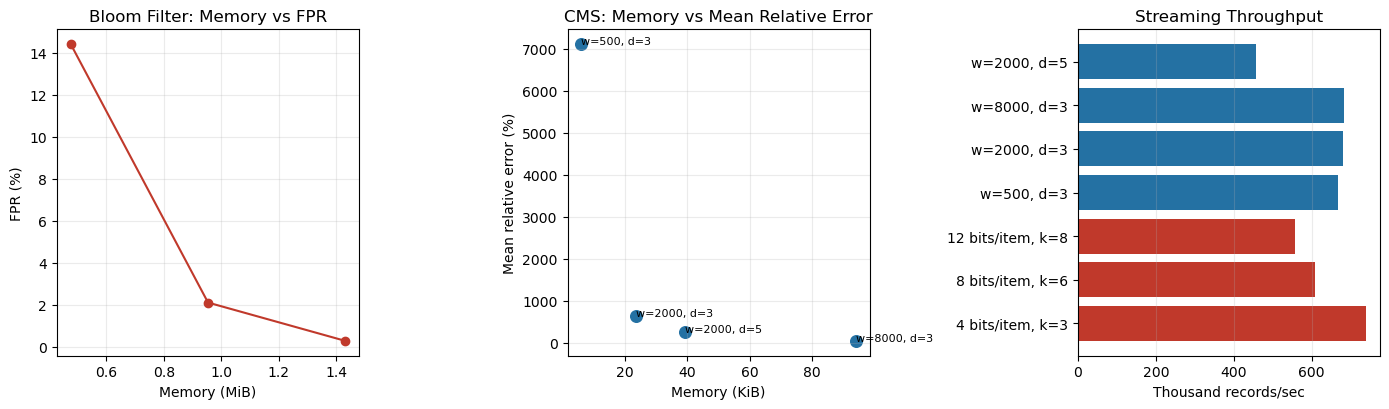

결론: 메모리 증가로 정확도는 개선되지만, 해시 수와 depth 증가는 처리량을 낮출 수 있다.


In [7]:
results = {
    "dataset": {
        "name": "MovieLens 1M", "records": record_count,
        "unique_pairs": len(truth_pairs), "unique_movies": len(truth_movie_counts),
        "truth_seconds": truth_seconds,
    },
    "bloom": bloom_results,
    "cms": cms_results,
}
Path("artifacts").mkdir(exist_ok=True)
Path("artifacts/results.json").write_text(json.dumps(results, indent=2), encoding="utf-8")

bdf, cdf = pd.DataFrame(bloom_results), pd.DataFrame(cms_results)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].plot(bdf["memory_bytes"]/1024**2, bdf["false_positive_rate"]*100, "o-", color="#C0392B")
axes[0].set(title="Bloom Filter: Memory vs FPR", xlabel="Memory (MiB)", ylabel="FPR (%)")
axes[0].grid(alpha=.25)
axes[1].scatter(cdf["memory_bytes"]/1024, cdf["mean_relative_error"]*100, s=70, color="#2471A3")
for _, r in cdf.iterrows():
    axes[1].annotate(r["parameter"], (r["memory_bytes"]/1024, r["mean_relative_error"]*100), fontsize=8)
axes[1].set(title="CMS: Memory vs Mean Relative Error", xlabel="Memory (KiB)", ylabel="Mean relative error (%)")
axes[1].grid(alpha=.25)
all_df = pd.concat([bdf, cdf], ignore_index=True)
axes[2].barh(all_df["parameter"], all_df["throughput_rps"]/1000, color=["#C0392B"]*3 + ["#2471A3"]*4)
axes[2].set(title="Streaming Throughput", xlabel="Thousand records/sec")
axes[2].grid(axis="x", alpha=.25)
fig.tight_layout()
fig.savefig("artifacts/tradeoff_summary.png", dpi=180, bbox_inches="tight")
plt.show()

print("결론: 메모리 증가로 정확도는 개선되지만, 해시 수와 depth 증가는 처리량을 낮출 수 있다.")